# IMC Prosperity 4: Round 0
This research notebook examines the historical price and trade data for *EMERALDS* and *TOMATOES* across Day -2 and Day -1. 

The aim is to understand the microstructure of both products, identify predictive signals and estimate an appropriate fair value for an algorithmic trading strategy.

In [36]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import math
import json
from io import StringIO

In [2]:
# Set plotting style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_context("notebook")

## 1. Data Understanding
This section clarifies what the prices and trades datasets represent, how timestamps align and which parts of the historical data correspond to information that would be available live in `TradingState`.

### 1.1 Data Loading and Preprocessing
The data is split across two days, so the first step is to load both files using the `;` delimiter and standardise their structure.

In [3]:
# Load price data
df_prices_day_minus_2 = pd.read_csv('data/prices_round_0_day_-2.csv', sep=';')
df_prices_day_minus_1 = pd.read_csv('data/prices_round_0_day_-1.csv', sep=';')

# Load trade data
df_trades_day_minus_2 = pd.read_csv('data/trades_round_0_day_-2.csv', sep=';')
df_trades_day_minus_1 = pd.read_csv('data/trades_round_0_day_-1.csv', sep=';')

### 1.2 Inspecting datasets
This section checks uniqueness, product coverage and missing values.

In [4]:
# Inspection
for name, df in [('Prices Day -2', df_prices_day_minus_2), ('Prices Day -1', df_prices_day_minus_1), ('Trades Day -2', df_trades_day_minus_2), ('Trades Day -1', df_trades_day_minus_1)]:
    print(f"Inspecting {name}:")
    print(df.shape)
    print(df.columns)
    print(df.head())
    print(df.dtypes)

Inspecting Prices Day -2:
(20000, 17)
Index(['day', 'timestamp', 'product', 'bid_price_1', 'bid_volume_1',
       'bid_price_2', 'bid_volume_2', 'bid_price_3', 'bid_volume_3',
       'ask_price_1', 'ask_volume_1', 'ask_price_2', 'ask_volume_2',
       'ask_price_3', 'ask_volume_3', 'mid_price', 'profit_and_loss'],
      dtype='str')
   day  timestamp   product  bid_price_1  bid_volume_1  bid_price_2  \
0   -2          0  EMERALDS         9992            11         9990   
1   -2          0  TOMATOES         4993             7         4992   
2   -2        100  TOMATOES         4998             5         4993   
3   -2        100  EMERALDS         9992            15         9990   
4   -2        200  TOMATOES         4994             6         4993   

   bid_volume_2  bid_price_3  bid_volume_3  ask_price_1  ask_volume_1  \
0            25          NaN           NaN        10008            11   
1            17          NaN           NaN         5007             7   
2             7    

### 1.3 Duplicate keys in dataframes

In [5]:
prices = pd.concat([df_prices_day_minus_2, df_prices_day_minus_1], ignore_index=True)
trades = pd.concat([df_trades_day_minus_2.assign(day=-2), df_trades_day_minus_1.assign(day=-1)], ignore_index=True)

print('products prices', prices['product'].unique())
print('products trades', trades['symbol'].unique())

products prices <StringArray>
['EMERALDS', 'TOMATOES']
Length: 2, dtype: str
products trades <StringArray>
['TOMATOES', 'EMERALDS']
Length: 2, dtype: str


In [6]:
# prices
print('duplicate keys', prices.duplicated(['day', 'timestamp', 'product']).sum())
print('timestamp min/max by day')
print(prices.groupby('day')['timestamp'].agg(['min', 'max','nunique']).to_string())

duplicate keys 0
timestamp min/max by day
     min     max  nunique
day                      
-2     0  999900    10000
-1     0  999900    10000


In [7]:
# trades
print('duplicate keys', trades.duplicated(['day', 'timestamp', 'symbol']).sum())
print('timestamp min/max by day')
print(trades.groupby('day')['timestamp'].agg(['min', 'max','nunique']).to_string())

duplicate keys 1
timestamp min/max by day
      min     max  nunique
day                       
-2    900  991700      576
-1   3200  995600      626


In [8]:
# Locate duplicate groups in trades
dup = trades.groupby(['day', 'timestamp', 'symbol']).size().reset_index(name='n')
dup[dup.n>1]

,day,timestamp,symbol,n
378,-2,673800,TOMATOES,2


In [9]:
# Inspecting trade and price timestamp matching
for day in [-2,-1]:
    price_ts=set(prices.loc[prices.day==day,'timestamp'])
    trade_ts=set(trades.loc[trades.day==day,'timestamp'])
    print(f'day {day}: {len(trade_ts)} trades, {len(trade_ts-price_ts)} timestamps missing, all multiple of 100?', all(t%100==0 for t in trade_ts))

day -2: 576 trades, 0 timestamps missing, all multiple of 100? True
day -1: 626 trades, 0 timestamps missing, all multiple of 100? True


### 1.4 Product trades analysis

In [10]:
# Coverage of trades over price states
price_states = prices[['day', 'timestamp','product']].copy()
trade_ag = trades.groupby(['day', 'timestamp','symbol']).agg(
    trade_count=('price','size'),
    trade_volume=('quantity','sum'),
    trade_vwap=('price', lambda s: np.average(s, weights=trades.loc[s.index,'quantity'])),
    trade_price_min=('price','min'),
    trade_price_max=('price','max')
).reset_index().rename(columns={'symbol':'product'})
master = price_states.merge(trade_ag, on=['day', 'timestamp','product'], how='left')
print('Proportion of timestamps with trades: {}'.format(master['trade_count'].notna().mean()))
print(master.groupby('product')['trade_count'].apply(lambda s: s.notna().mean()))

Proportion of timestamps with trades: 0.03045
product
EMERALDS    0.01995
TOMATOES    0.04095
Name: trade_count, dtype: float64


In [11]:
# Distribution of trades at bid/ask
m = trades.merge(prices.rename(columns={'product':'symbol'}), on=['day', 'timestamp','symbol'], how='left')
def loc(row):
    p=row['price']
    for level in [1,2,3]:
        bid=row.get(f'bid_price_{level}')
        ask=row.get(f'ask_price_{level}')
        if pd.notna(bid) and p==bid: return f'bid_{level}'
        if pd.notna(ask) and p==ask: return f'ask_{level}'
    return 'other'
m['book_loc']=m.apply(loc, axis=1)
print(m['book_loc'].value_counts())
print(m.groupby('symbol')['book_loc'].value_counts().unstack(fill_value=0))

book_loc
bid_1    637
ask_1    582
Name: count, dtype: int64
book_loc  ask_1  bid_1
symbol                
EMERALDS    195    204
TOMATOES    387    433


We found that:

1. `637` trades occurred at `bid_1`, which suggests seller aggression
2. `582` trades occurred at `ask_1`, which suggests buyer aggression
3. none occurred at deeper levels
4. none occurred inside the spread
5. none occurred outside the visible best bid and best ask

### 1.5 Conclusions

**A. Dataset map**

- the prices files are snapshot data
- the trades files are event data
- timestamps align exactly between the two datasets
- both products appear consistently across both days

**B. Granularity confirmation**

- prices are unique by `(day, timestamp, product)`
- trades are event rows, with only one duplicated state that can simply be aggregated

**C. Canonical schema**

- rename `symbol` to `product`
- create a continuous timeline `global_timestamp`
- treat level 3 book columns as optional

**D. Master market table**

- use the prices data as the base
- aggregate trades to `(day, timestamp, product)`
- merge trade summaries onto price snapshots

**E. Leakage rule**

- all features must be constructed using information available at or before time `t`

In [12]:
# Rename symbol to product for consistency
trades.rename(columns={'symbol':'product'}, inplace=True)

In [13]:
DAY_LENGTH = 1_000_000

# Create continous timeline
prices["global_timestamp"] = (prices["day"] - prices["day"].min()) * DAY_LENGTH + prices["timestamp"]
trades["global_timestamp"] = (trades["day"] - trades["day"].min()) * DAY_LENGTH + trades["timestamp"]

In [14]:
# define (global_timestamp, product) as master key
master_key = ['global_timestamp', 'product']

## 2. Market behaviour study

This section examines spreads, depth, price changes, trade location relative to the book, volume behaviour and whether order book pressure predicts short term movement.

### 2.1 New features and summary statistics

In [15]:
# Create microstructure features
prices['spread'] = prices['ask_price_1'] - prices['bid_price_1']
prices['l1_imbalance'] = (prices['bid_volume_1'] - prices['ask_volume_1']) / (prices['bid_volume_1'] + prices['ask_volume_1'])
prices['depth2_bid'] = prices[['bid_volume_1','bid_volume_2']].fillna(0).sum(axis=1)
prices['depth2_ask'] = prices[['ask_volume_1','ask_volume_2']].fillna(0).sum(axis=1)
prices['depth2_imbalance']=(prices['depth2_bid']-prices['depth2_ask'])/(prices['depth2_bid']+prices['depth2_ask'])

# next mid change per day/product
prices['next_mid'] = prices.groupby(['day','product'])['mid_price'].shift(-1)
prices['next_mid_change'] = prices['next_mid'] - prices['mid_price']
prices['next_mid_dir'] = np.sign(prices['next_mid_change']).fillna(0)
prices['mid_change'] = prices.groupby(['day','product'])['mid_price'].diff()
prices['mid_change_abs'] = prices['mid_change'].abs()

# next best bid/ask changes
prices['next_bid1'] = prices.groupby(['day','product'])['bid_price_1'].shift(-1)
prices['next_ask1'] = prices.groupby(['day','product'])['ask_price_1'].shift(-1)
prices['next_bid1_change'] = prices['next_bid1'] - prices['bid_price_1']
prices['next_ask1_change'] = prices['next_ask1'] - prices['ask_price_1']

In [16]:
# Join trades with prices snapshot
trade_join = trades.merge(prices, on=master_key, how='left')
trade_join['side'] = np.where(np.isclose(trade_join['price'], trade_join['ask_price_1']), 'buy_aggr',
                              np.where(np.isclose(trade_join['price'], trade_join['bid_price_1']), 'sell_aggr', 'other'))
print(trade_join['side'].value_counts(dropna=False))

side
sell_aggr    637
buy_aggr     582
Name: count, dtype: int64


In [17]:
summary={}
for prod, df in prices.groupby('product'):
    out={}
    out['rows']=len(df)
    out['mid_mean']=df['mid_price'].mean()
    out['mid_std']=df['mid_price'].std()
    out['mid_min']=df['mid_price'].min()
    out['mid_max']=df['mid_price'].max()
    out['mid_change_pct']=(df['next_mid_change']!=0).mean()
    out['next_mid_up_pct']=(df['next_mid_change']>0).mean()
    out['next_mid_down_pct']=(df['next_mid_change']<0).mean()
    out['spread_mean']=df['spread'].mean()
    out['spread_median']=df['spread'].median()
    out['spread_dist']=df['spread'].value_counts(normalize=True).sort_index().head(10).to_dict()
    out['bid1_vol_mean']=df['bid_volume_1'].mean()
    out['ask1_vol_mean']=df['ask_volume_1'].mean()
    out['l1_imb_std']=df['l1_imbalance'].std()
    out['trade_active_pct']=df.merge(trades.groupby(master_key).size().rename('n').reset_index(),
                                     on=master_key, how='left')['n'].notna().mean()
    summary[prod]=out
summary

{'EMERALDS': {'rows': 20000,
  'mid_mean': np.float64(9999.9976),
  'mid_std': np.float64(0.7233397549008702),
  'mid_min': np.float64(9996.0),
  'mid_max': np.float64(10004.0),
  'mid_change_pct': np.float64(0.0634),
  'next_mid_up_pct': np.float64(0.03165),
  'next_mid_down_pct': np.float64(0.03165),
  'spread_mean': np.float64(15.7384),
  'spread_median': np.float64(16.0),
  'spread_dist': {8: 0.0327, 16: 0.9673},
  'bid1_vol_mean': np.float64(12.45705),
  'ask1_vol_mean': np.float64(12.4598),
  'l1_imb_std': np.float64(0.04922536765531201),
  'trade_active_pct': np.float64(0.01995)},
 'TOMATOES': {'rows': 20000,
  'mid_mean': np.float64(4992.758125),
  'mid_std': np.float64(19.747055003048928),
  'mid_min': np.float64(4946.5),
  'mid_max': np.float64(5036.0),
  'mid_change_pct': np.float64(0.67905),
  'next_mid_up_pct': np.float64(0.3383),
  'next_mid_down_pct': np.float64(0.34065),
  'spread_mean': np.float64(13.02025),
  'spread_median': np.float64(13.0),
  'spread_dist': {5: 0.0

### 2.2 Price and Spread Behaviours

Questions about price behaviour:
- Is the product mostly stationary around a fixed level?
- Are price changes rare or frequent?
- Are moves mostly single step or larger jumps?
- After a move, does the next move tend to continue or reverse?

Questions about spread behaviour:
- Is spread usually constant?
- Does spread widen before moves?
- Is there enough spread to support passive quoting?
- Is one product structurally wider than the other?

PRODUCT EMERALDS
next_mid_change
-8.0        3
-4.0      630
 0.0    18732
 4.0      630
 8.0        3
Name: count, dtype: int64
Autocorrelation lag1 of mid_change -0.48753894080996885

PRODUCT TOMATOES
next_mid_change
-8.5       1
-7.5       2
-7.0       5
-6.5       8
-6.0       3
-5.5       5
-5.0      28
-4.5      84
-4.0     205
-3.5     311
-3.0     314
-2.5     261
-2.0     117
-1.5     161
-1.0    1222
-0.5    4086
 0.0    6419
 0.5    4071
 1.0    1194
 1.5     153
Name: count, dtype: int64
Autocorrelation lag1 of mid_change -0.42024063941083856



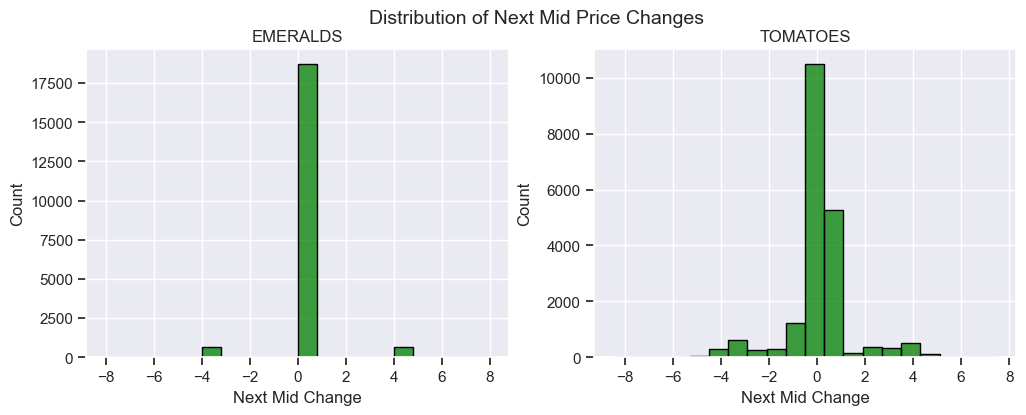

In [18]:
# Distribution of next mid price changes and autocorrelation
for prod, df in prices.groupby('product'):
    print("PRODUCT", prod)
    ch = df['next_mid_change'].dropna()
    print(ch.value_counts().sort_index().head(20))
    print("Autocorrelation lag1 of mid_change", df['mid_change'].fillna(0).autocorr())
    # conditional move analysis
    tmp=df[['next_mid_change']].copy()
    tmp['current']=df['mid_change'].fillna(0)
    tmp=tmp.iloc[1:-1].copy()
    tmp['next']=df['next_mid_change'].iloc[1:-1].values
    print()

groups = prices.groupby('product')
num_products = len(groups) # making reproducible for more products in future rounds
cols = 2
rows = math.ceil(num_products / cols)

plt.figure(figsize=(12, rows*4))
plt.suptitle('Distribution of Next Mid Price Changes', fontsize=14)

for i, (prod, df) in enumerate(groups):
    plt.subplot(rows, cols, i+1)
    sns.histplot(df['next_mid_change'], bins=20, color='green')
    plt.title(prod)
    plt.xlabel('Next Mid Change')

In [19]:
for prod, df in prices.groupby('product'):
    print(prod, 'spread dist top')
    print((df['spread'].value_counts(normalize=True)*100).sort_index().round(2))
    print('bid1 vol dist top', df['bid_volume_1'].value_counts().head(10).to_dict())
    print('ask1 vol dist top', df['ask_volume_1'].value_counts().head(10).to_dict())
    print()

EMERALDS spread dist top
spread
8      3.27
16    96.73
Name: proportion, dtype: float64
bid1 vol dist top {14: 3388, 15: 3349, 13: 3331, 10: 3238, 12: 3230, 11: 3198, 7: 58, 8: 55, 5: 55, 6: 50}
ask1 vol dist top {14: 3392, 15: 3354, 13: 3337, 10: 3236, 12: 3218, 11: 3187, 9: 64, 7: 61, 8: 57, 6: 55}

TOMATOES spread dist top
spread
5      0.92
6      1.26
7      2.04
8      2.33
9      0.66
13    48.02
14    44.77
Name: proportion, dtype: float64
bid1 vol dist top {6: 3334, 7: 3293, 5: 3272, 9: 3269, 10: 3269, 8: 3221, 3: 107, 2: 94, 4: 80, 11: 35}
ask1 vol dist top {6: 3311, 9: 3286, 7: 3285, 10: 3269, 5: 3267, 8: 3229, 3: 102, 4: 94, 2: 91, 11: 36}



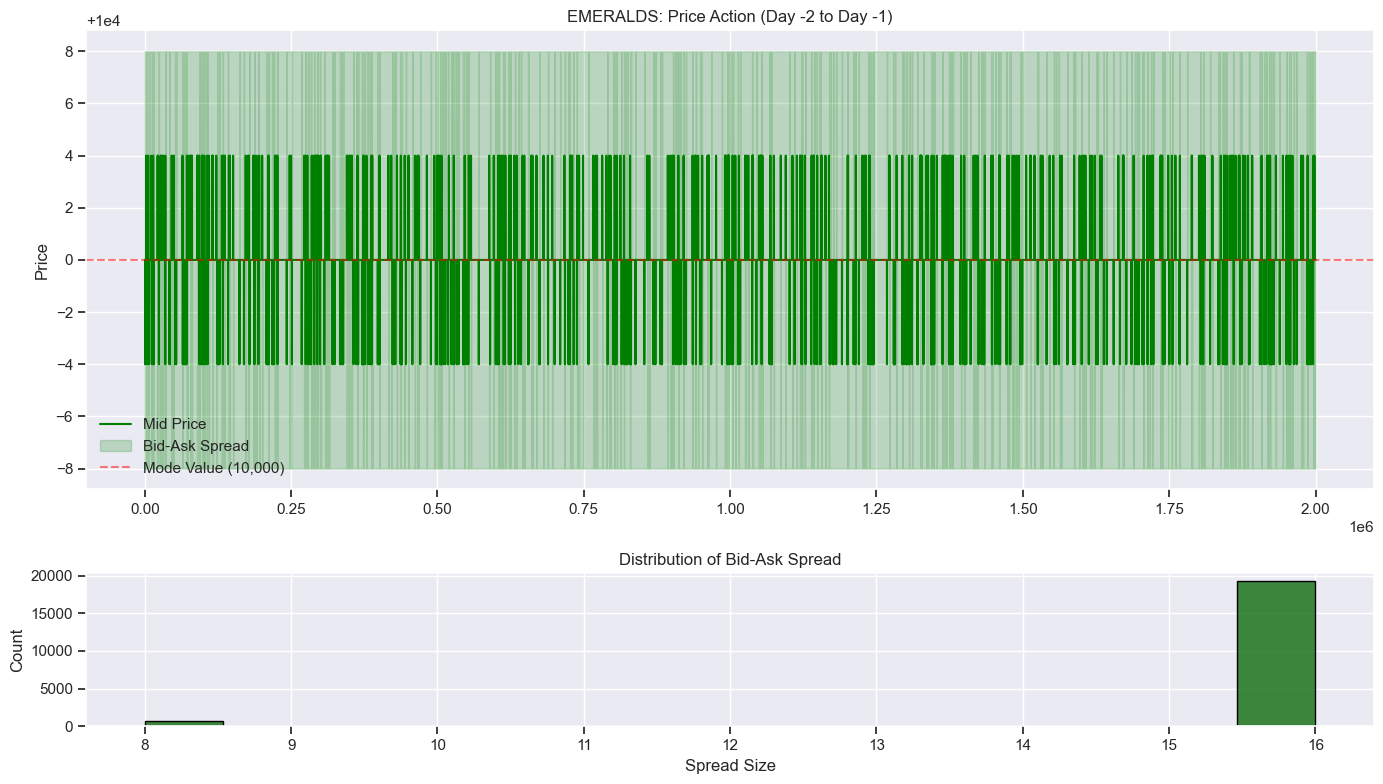

In [20]:
# EMERALDS
emeralds_prices = prices[prices['product'] == 'EMERALDS']
emeralds_trades = trades[trades['product'] == 'EMERALDS']

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8), gridspec_kw={'height_ratios': [3, 1]})

# Plot 1: Price Timeline
ax1.plot(emeralds_prices['global_timestamp'], emeralds_prices['mid_price'], color='green', label='Mid Price', linewidth=1.5)
ax1.fill_between(emeralds_prices['global_timestamp'], emeralds_prices['bid_price_1'], emeralds_prices['ask_price_1'], color='green', alpha=0.2, label='Bid-Ask Spread')
ax1.axhline(y=10000, color='red', linestyle='--', alpha=0.5, label='Mode Value (10,000)')
ax1.set_title('EMERALDS: Price Action (Day -2 to Day -1)')
ax1.set_ylabel('Price')
ax1.legend()

# Plot 2: Spread Distribution
sns.histplot(emeralds_prices['spread'], bins=15, ax=ax2, color='darkgreen')
ax2.set_title('Distribution of Bid-Ask Spread')
ax2.set_xlabel('Spread Size')

plt.tight_layout()
plt.show()


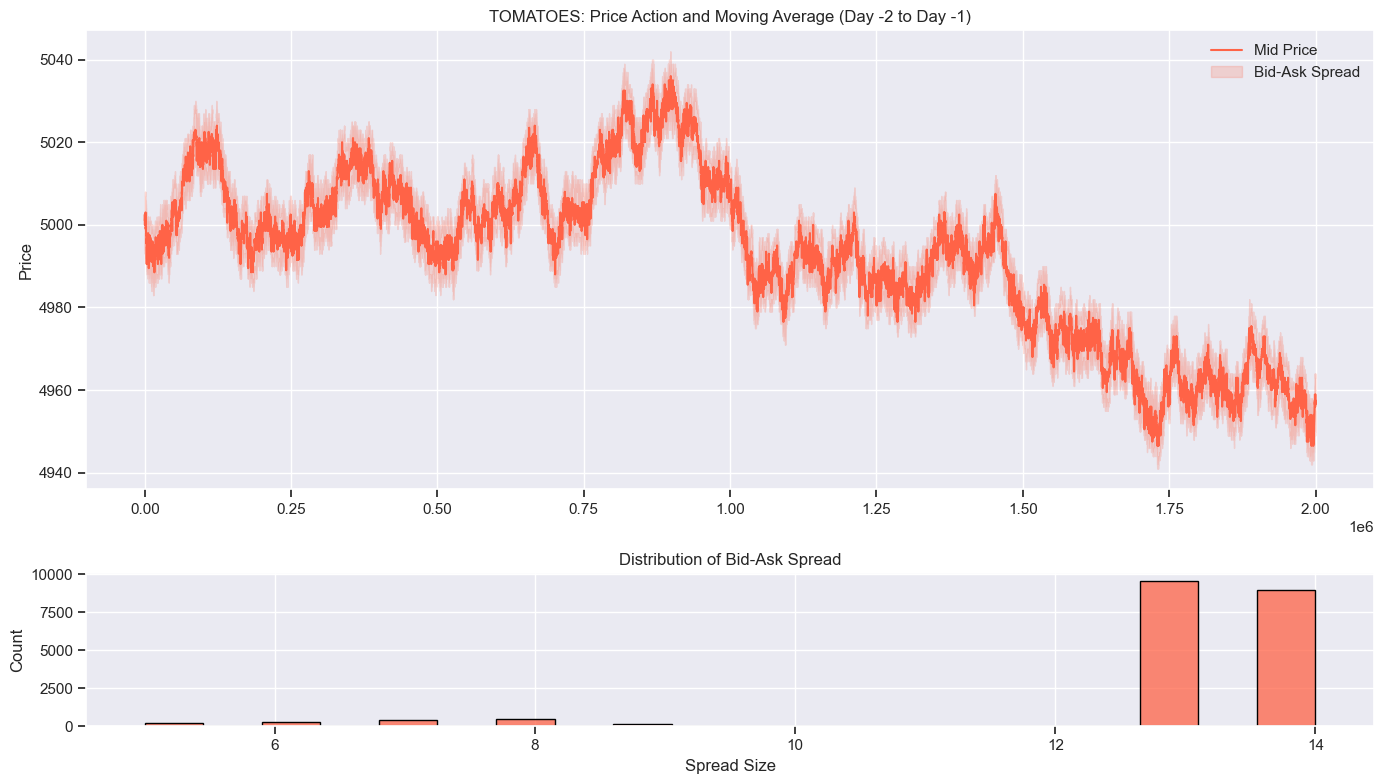

In [21]:
# TOMATOES
tomatoes_prices = prices[prices['product'] == 'TOMATOES']
tomatoes_trades = trades[trades['product'] == 'TOMATOES']

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8), gridspec_kw={'height_ratios': [3, 1]})

# Plot 1: Price Timeline
ax1.plot(tomatoes_prices['global_timestamp'], tomatoes_prices['mid_price'], color='tomato', label='Mid Price', linewidth=1.5)
ax1.fill_between(tomatoes_prices['global_timestamp'], tomatoes_prices['bid_price_1'], tomatoes_prices['ask_price_1'], color='tomato', alpha=0.2, label='Bid-Ask Spread')
ax1.set_title('TOMATOES: Price Action and Moving Average (Day -2 to Day -1)')
ax1.set_ylabel('Price')
ax1.legend()

# Plot 2: Spread Distribution
sns.histplot(tomatoes_prices['spread'], bins=20, ax=ax2, color='tomato')
ax2.set_title('Distribution of Bid-Ask Spread')
ax2.set_xlabel('Spread Size')

plt.tight_layout()
plt.show()

#### Price behaviour

EMERALDS is extremely stable.

- the mean mid price is essentially 10000
- the standard deviation of the mid price is only about 0.72
- the mid price changes only about 6.3% of the time
- the remaining 93.7% of the time it stays flat at 10000
- when it moves, the change is almost always 4 ticks

More specifically, the distribution of the next mid change is dominated by:

- 0 most of the time
- +4 or -4 occasionally
- +8 or -8 only very rarely

TOMATOES is much more volatile.

- the mean mid price is about 4992.8
- the standard deviation is much larger
- price changes occur far more often
- the distribution of moves is broader and noisier

This already suggests that EMERALDS behaves more like a stable event driven product, whereas TOMATOES behaves like a more active trading environment.

#### Spread behaviour

EMERALDS has an almost fixed spread.

- the spread is 16 about 96.7% of the time
- the spread is 8 only about 3.3% of the time
- the mean spread is about 15.74
- the median spread is 16

TOMATOES is also structured, but less rigid.

- the spread is 13 about 48.0% of the time
- the spread is 14 about 44.8% of the time
- smaller spreads between 5 and 9 do occur, but much less often
- the mean spread is about 13.02
- the median spread is 13

Both products therefore offer a meaningful spread, which is encouraging for passive quoting. The difference is that EMERALDS is much more stable, while TOMATOES combines a wide spread with a more mobile fair value.

### 2.3 Does recent price movement continue or reverse?

In [22]:
# Calculating continuation, reversal, and zero move probabilities
for prod, df in prices.groupby('product'):
    d=df.copy()
    d['curr_move']=d['mid_change']
    d['next_move']=d['next_mid_change']
    d=d.dropna(subset=['curr_move','next_move'])
    moved=d[d['curr_move']!=0]
    same=((np.sign(moved['curr_move'])==np.sign(moved['next_move'])) & (moved['next_move']!=0)).mean()
    opp=((np.sign(moved['curr_move'])==-np.sign(moved['next_move'])) & (moved['next_move']!=0)).mean()
    zero=(moved['next_move']==0).mean()
    print(f'Product: {prod}, Moved: {len(moved)}, Same: {same}, Opp: {opp}, Zero: {zero}')


Product: EMERALDS, Moved: 1266, Same: 0.011848341232227487, Opp: 0.4968404423380727, Zero: 0.4913112164296998
Product: TOMATOES, Moved: 13577, Same: 0.2778964425130736, Opp: 0.4143772556529425, Zero: 0.3077263018339839


EMERALDS

- the next step moves in the opposite direction about 49.7% of the time
- the next step is flat about 49.1% of the time
- continuation occurs only about 1.2% of the time

This is very strong short horizon mean reversion.

TOMATOES

- the next move is in the opposite direction about 41.4% of the time
- the next step is flat about 30.8% of the time
- continuation occurs about 27.8% of the time

TOMATOES therefore also leans towards mean reversion, though much less strongly than EMERALDS.

### 2.4 Depth and book shape

- Is top of book volume stable or noisy?
- Are there recurring standard depth sizes?
- Does a weak ask side often precede upward movement?
- Does a weak bid side often precede downward movement?

In [23]:
for prod in prices['product'].unique():
    df=prices[prices['product']==prod]
    print(prod, 'l1 unique top', df['l1_imbalance'].value_counts().head(10).to_dict())
    print(prod, 'depth2 unique top', df['depth2_imbalance'].value_counts().head(10).to_dict())

EMERALDS l1 unique top {0.0: 19359, -0.3333333333333333: 34, 0.3333333333333333: 23, -0.25: 19, 0.25: 17, 0.18181818181818182: 17, -0.2: 16, 0.2: 16, 0.17647058823529413: 16, -0.23809523809523808: 15}
EMERALDS depth2 unique top {0.0: 19346, -0.3333333333333333: 18, 0.3333333333333333: 17, 0.25: 11, -0.2727272727272727: 10, -0.25: 9, 0.32142857142857145: 8, 0.2982456140350877: 8, 0.30158730158730157: 8, -0.23636363636363636: 7}
TOMATOES l1 unique top {0.0: 18679, -0.3333333333333333: 57, -0.25: 48, 0.2: 46, 0.3333333333333333: 45, 0.09090909090909091: 44, -0.09090909090909091: 43, -0.2: 43, 0.25: 39, 0.5: 35}
TOMATOES depth2 unique top {0.0: 18557, -0.3333333333333333: 45, 0.3333333333333333: 41, 0.5: 21, 0.42857142857142855: 21, -0.42857142857142855: 21, -0.5: 20, 0.4: 15, 0.4418604651162791: 14, 0.3157894736842105: 13}


EMERALDS

Best level depth is very regular.

- average best bid volume is about 12.46
- average best ask volume is about 12.46
- the most common best level volumes are between 10 and 15

Top of book imbalance is also usually exactly zero.

- level 1 imbalance is 0 in about 19,359 out of 20,000 states
- when imbalance is non zero, it is relatively rare but very informative

TOMATOES

Depth is smaller and noisier.

- average best bid volume is about 7.44
- average best ask volume is about 7.45
- the most common best level volumes are between 5 and 10

Again, imbalance is often zero, but much less overwhelmingly so than in EMERALDS.

### 2.5 Trade activity profile

- Are trades isolated or clustered?
- Are most trades small or large?
- Are buy side and sell side trades balanced?
- Does activity come in bursts?

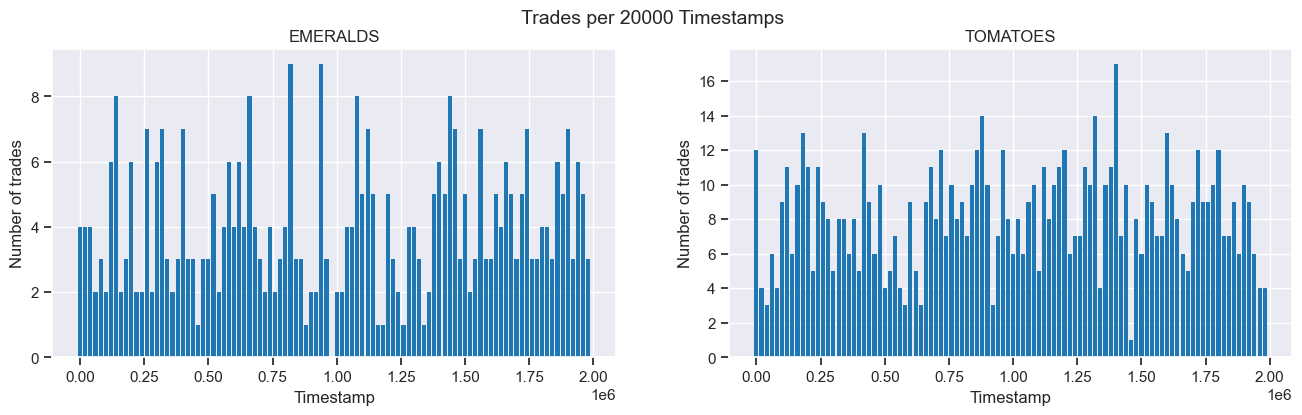

In [24]:
trades_groups = trades.groupby("product")
num_products = len(trades_groups)
cols = 2
rows = math.ceil(num_products / cols)

bin_size = 20_000
max_timestamp = trades["global_timestamp"].max()
all_bins = range(0, max_timestamp // bin_size + 1)

plt.figure(figsize=(16, rows * 4))
plt.suptitle(f"Trades per {bin_size} Timestamps", fontsize=14)

for i, (prod, d) in enumerate(trades_groups):
    counts = (
        d.groupby(d["global_timestamp"] // bin_size)
         .size()
         .reindex(all_bins, fill_value=0)
    )

    plt.subplot(rows, cols, i + 1)
    plt.bar([b * bin_size for b in counts.index], counts.values, width=bin_size * 0.8)
    plt.title(prod)
    plt.xlabel("Timestamp")
    plt.ylabel("Number of trades")

plt.show()

EMERALDS

Trades are very sparse.

- only about 2.0% of timestamps contain a trade
- there are 399 trades across both sample days
- average trade size is about 5.5
- trades do not appear strongly clustered

TOMATOES

Trades are still sparse relative to all timestamps, but much more active than EMERALDS.

- about 4.1% of timestamps contain a trade
- there are 820 trades across both days
- average trade size is about 3.5
- trades do not appear strongly clustered

Since most states contain no trades at all, trade flow is unlikely to be the main signal engine. It may still add useful context, but the order book should remain the core of the model.

### 2.6 Trade to next move relationship

- Is buyer aggression informative?
- Is seller aggression informative?
- Are trades at bid or ask informative or mostly liquidity consuming noise?

In [25]:
for prod, df in trade_join.groupby('product'):
    print("PRODUCT", prod)
    print(df.groupby('side').agg(
        n=('price','size'),
        mean_next_mid=('next_mid_change','mean'),
        up=('next_mid_change', lambda x: (x>0).mean()),
        down=('next_mid_change', lambda x: (x<0).mean()),
        zero=('next_mid_change', lambda x: (x==0).mean()),
        avg_qty=('quantity','mean')
    ))
    print()

PRODUCT EMERALDS
             n  mean_next_mid        up      down      zero   avg_qty
side                                                                 
buy_aggr   195       0.020513  0.035897  0.030769  0.933333  5.523077
sell_aggr  204      -0.039216  0.034314  0.044118  0.921569  5.450980

PRODUCT TOMATOES
             n  mean_next_mid        up      down      zero   avg_qty
side                                                                 
buy_aggr   387      -0.065891  0.291990  0.372093  0.335917  3.537468
sell_aggr  433      -0.062356  0.311778  0.367206  0.321016  3.427252



EMERALDS

For trades at the ask, the next mid move is on average about +0.02.  
For trades at the bid, the next mid move is on average about -0.04.

That effect is extremely small. In addition:

- after ask trades, the market is still flat about 93.3% of the time
- after bid trades, the market is still flat about 92.2% of the time

So trade side alone does not provide a strong one step edge in EMERALDS.

TOMATOES

- after ask side trades, the next mid move is on average about -0.066
- after bid side trades, the next mid move is on average about -0.062

So simple trade side is not useful as a directional predictor here either.

Overall, raw trade flow does not appear to be a primary alpha source in this dataset.

### 2.7 Book imbalance to next move relationship

- Does the book contain directional information?
- How far ahead does that information persist?
- Is the effect strong enough to overcome spread cost?

In [26]:
def imbalance_bins(df, col, q=5):
    tmp=df[[col,'next_mid_change']].dropna().copy()
    tmp['bin']=pd.qcut(tmp[col], q, duplicates='drop')
    out=tmp.groupby('bin').agg(
        n=('next_mid_change','size'),
        mean_next=('next_mid_change','mean'),
        up=('next_mid_change', lambda x: (x>0).mean()),
        down=('next_mid_change', lambda x: (x<0).mean()),
        nonzero=('next_mid_change', lambda x: (x!=0).mean())
    )
    return out

for prod, df in prices.groupby('product'):
    print("==",prod,'l1')
    print(imbalance_bins(df,'l1_imbalance'))
    print("==",prod,'depth2')
    print(imbalance_bins(df,'depth2_imbalance'))

== EMERALDS l1
                   n  mean_next        up      down   nonzero
bin                                                          
(-0.501, 0.0]  19671  -0.065274  0.016013  0.032179  0.048193
(0.0, 0.5]       327   3.926606  0.972477  0.000000  0.972477
== EMERALDS depth2
                   n  mean_next        up      down   nonzero
bin                                                          
(-0.445, 0.0]  19665  -0.066514  0.015713  0.032189  0.047902
(0.0, 0.444]     333   3.927928  0.972973  0.000000  0.972973
== TOMATOES l1
                   n  mean_next        up      down   nonzero
bin                                                          
(-0.668, 0.0]  19347  -0.059079  0.324236  0.344291  0.668527
(0.0, 0.75]      651   1.690476  0.757296  0.233487  0.990783
== TOMATOES depth2
                   n  mean_next        up      down   nonzero
bin                                                          
(-0.612, 0.0]  19284  -0.126711  0.314924  0.352676  0.667600
(0

In [27]:
# correlations
for prod, df in prices.groupby('product'):
    tmp=df[['l1_imbalance','depth2_imbalance','next_mid_change']].dropna()
    print(prod, 'corr l1-next', tmp['l1_imbalance'].corr(tmp['next_mid_change']))
    print(prod, 'corr d2-next', tmp['depth2_imbalance'].corr(tmp['next_mid_change']))
    # positive imbalance states
    for col in ['l1_imbalance','depth2_imbalance']:
        pos=tmp[tmp[col]>0]['next_mid_change']
        zero=tmp[tmp[col]==0]['next_mid_change']
        neg=tmp[tmp[col]<0]['next_mid_change']
        print(col, 'pos n', len(pos), 'mean', pos.mean(), 'up', (pos > 0).mean(), 'down', (pos < 0).mean())
        print(col, 'zero n', len(zero), 'mean', zero.mean(), 'up', (zero > 0).mean(), 'down', (zero < 0).mean())
        print(col, 'neg n', len(neg), 'mean', neg.mean(), 'up', (neg > 0).mean(), 'down', (neg < 0).mean())
        print()

EMERALDS corr l1-next 0.6305757233996108
EMERALDS corr d2-next 0.6863598178905791
l1_imbalance pos n 327 mean 3.926605504587156 up 0.9724770642201835 down 0.0
l1_imbalance zero n 19357 mean -0.002686366689053056 up 0.016273182827917548 down 0.016944774500180813
l1_imbalance neg n 314 mean -3.9235668789808917 up 0.0 down 0.9713375796178344

depth2_imbalance pos n 333 mean 3.9279279279279278 up 0.972972972972973 down 0.0
depth2_imbalance zero n 19344 mean -0.0024813895781637717 up 0.015973945409429282 down 0.016594292803970224
depth2_imbalance neg n 321 mean -3.925233644859813 up 0.0 down 0.9719626168224299

TOMATOES corr l1-next 0.3258437374967765
TOMATOES corr d2-next 0.5846425040835798
l1_imbalance pos n 651 mean 1.6904761904761905 up 0.7572964669738863 down 0.23348694316436253
l1_imbalance zero n 18677 mean -0.016196391283396692 up 0.32746158376612944 down 0.32954971355142687
l1_imbalance neg n 670 mean -1.2544776119402985 up 0.23432835820895523 down 0.755223880597015

depth2_imbalan

EMERALDS

**Level 1 imbalance**

The correlation between level 1 imbalance and the next mid change is about **0.63**.

When level 1 imbalance is positive:

- average next mid move is about +3.93
- the next move is up about 97.2% of the time
- the next move is down 0% of the time

When level 1 imbalance is negative:

- average next mid move is about -3.92
- the next move is down about 97.1% of the time
- the next move is up 0% of the time

That is extremely strong.

**Level 1 plus level 2 imbalance**

This is even stronger.

The correlation with the next mid change is about **0.69**.

So for EMERALDS, non zero imbalance is almost a direct signal of the next jump direction.

TOMATOES

**Level 1 imbalance**

The correlation with the next mid change is about **0.33**.

When level 1 imbalance is positive:

- average next mid move is about +1.69
- the next move is up about 75.7%
- the next move is down about 23.3%

When level 1 imbalance is negative:

- average next mid move is about -1.25
- the next move is down about 75.5%
- the next move is up about 23.4%

This is clearly informative, though weaker than in EMERALDS.

**Level 1 plus level 2 imbalance**

This becomes much stronger.

The correlation with the next mid change is about **0.58**.

When depth 2 imbalance is positive:

- average next mid move is about +3.36
- the next move is up about 97.1%
- the next move is down only about 1.7%

When depth 2 imbalance is negative:

- average next mid move is about -2.93
- the next move is down about 97.0%
- the next move is up only about 1.9%

This is the strongest result in the section and strongly supports using depth 2 imbalance as the primary predictive signal.

### 2.8 Conclusions

#### EMERALDS profile

- very stable mid price
- very sparse trading
- wide and almost fixed spread
- strong mean reversion after moves
- extremely informative non zero imbalance
- weak raw trade flow signal

EMERALDS therefore appears most suitable for:

- book driven trading
- a simple fair value anchor with a strong imbalance reaction
- careful passive quoting around a stable centre
- selective aggressive action only when imbalance is strong

It does **not** look like a product that requires complex trade flow logic.

#### TOMATOES profile

- much more active and noisy
- still wide quoted spread
- more frequent trades
- more continuous movement
- still somewhat mean reverting
- very informative order book imbalance, especially using levels 1 and 2
- weak raw trade side signal

TOMATOES appears more suitable for:

- a hybrid style strategy
- book based fair value
- signal aware market making
- selective aggressive trading when imbalance is strong

In both products, the order book matters far more than the trade tape.

## 3. Baseline fair value
Create the simplest reasonable fair value estimate and test whether quoting around it would have worked.

### 3.1 Fair Value Candidates

#### Candidate A: Plain mid price

This is the simplest baseline:

$$\text{mid} = \frac{\text{best bid + best ask}}{2}$$

**Assumption:** The current best bid and best ask are symmetric around the true short term value.

In [28]:
df_fv = prices.copy()
df_fv['mid_fv'] = df_fv['mid_price']

#### Candidate B: Level 1 Weighted Mid (Microprice)

$$\text{microprice}_1 = \frac{\text{best ask} \cdot \text{bid volume}_1 + \text{best bid} \cdot \text{ask volume}_1}{\text{bid volume}_1 + \text{ask volume}_1}$$

**Assumption:** The best level volumes contain directional information about near term movement.

Conceptually, if bid volume is large and ask volume is small, fair value should sit closer to the ask because upward movement is more likely.

In [29]:
av1 = df_fv['ask_volume_1']
bv1 = df_fv['bid_volume_1']
df_fv['micro1'] = (df_fv['ask_price_1']*bv1 + df_fv['bid_price_1']*av1) / (av1+bv1)

#### Candidate C: Level 1 + Level 2 Imbalance Adjusted Fair Value

This is a richer version of candidate B, using the fact that in our data level 1 + level 2 imbalance was especially predictive, particularly for TOMATOES

$$
\text{microprice}_{1,2} = \frac{
    \frac{\text{ask price}_1 \cdot \text{ask volume}_1 + \text{ask price}_2 \cdot \text{ask volume}_2}{\text{ask volume}_1+\text{ask volume}_2}\cdot(\text{bid volume}_1+\text{bid volume}_2) + \frac{\text{bid price}_1 \cdot \text{bid volume}_1 + \text{bid price}_2 \cdot \text{bid volume}_2}{\text{bid volume}_1+\text{bid volume}_2} \cdot(\text{ask volume}_1+\text{ask volume}_2)}
    {(\text{bid volume}_1+\text{bid volume}_2 + (\text{ask volume}_1+\text{ask volume}_2)}
$$



$$
\text{microprice}_{1,2} = \frac{\text{weighted average bid}_{1,2} * \text{bid volume}_{1,2} + \text{weighted average ask}_{1,2} * \text{ask volume}_{1,2}}{\text{bid volume}_{1,2} + \text{ask volume}_{1,2}}
$$

This depth 2 version uses information from both visible levels and should therefore respond better when pressure is building just beyond the best quote.



In [30]:
# microprice for first 2 levels with volume weighting
bid_notional = df_fv['bid_price_1']*df_fv['bid_volume_1'] + df_fv['bid_price_2']*df_fv['bid_volume_2']
bid_vol = df_fv['bid_volume_1'] + df_fv['bid_volume_2']
ask_notional = df_fv['ask_price_1']*df_fv['ask_volume_1'] + df_fv['ask_price_2']*df_fv['ask_volume_2']
ask_vol = df_fv['ask_volume_1'] + df_fv['ask_volume_2']
df_fv['w_bid_12'] = bid_notional / bid_vol.replace(0,np.nan)
df_fv['w_ask_12'] = ask_notional / ask_vol.replace(0,np.nan)
df_fv['micro12'] = (df_fv['w_ask_12']*bid_vol + df_fv['w_bid_12']*ask_vol)/(bid_vol+ask_vol)

# imbalance
df_fv['imb1']=(df_fv['bid_volume_1']-df_fv['ask_volume_1'])/(df_fv['bid_volume_1']+df_fv['ask_volume_1'])
df_fv['imb12']=(bid_vol-ask_vol)/(bid_vol+ask_vol)

### 3.2 Performance

We assess whether each candidate does a better job than plain mid at tracking the **next mid price**.

The key checks are:

- how well the candidate's premium over mid predicts the next mid change
- how close the candidate is to the next mid
- whether the sign of the candidate's tilt matches the sign of the next move

In [31]:
# candidate premium vs mid
for c in ['mid_fv','micro1','micro12']:
    df_fv[c+'_prem']=df_fv[c]-df_fv['mid_price']

# perhaps evaluate sign prediction of next_mid_change on nonzero outcome and nonzero premium
rows=[]
for prod,g in df_fv.groupby('product'):
    g=g.dropna(subset=['next_mid_change'])
    for c in ['mid_fv','micro1','micro12']:
        prem=g[c+'_prem']
        nxt=g['next_mid_change']
        
        if prem.std() > 0 and nxt.std() > 0:
            corr = prem.corr(nxt)
        else:
            corr = np.nan

        rows.append((prod,c,'corr_premium_next_change',corr))
        
        mask=(prem!=0)&(nxt!=0)
        if prem.std() > 0 and mask.sum():
            acc=(np.sign(prem[mask])==np.sign(nxt[mask])).mean()
            rows.append((prod,c,'sign_acc_nonzero',acc))
            rows.append((prod,c,'coverage_nonzero',mask.mean()))

        rmse=np.sqrt(np.mean((g[c]-g['next_mid'])**2))
        mae=np.mean(np.abs(g[c]-g['next_mid']))
        rows.append((prod,c,'rmse_to_next_mid',rmse))
        rows.append((prod,c,'mae_to_next_mid',mae))
res = pd.DataFrame(rows, columns=['product','candidate','metric','value'])
res.pivot_table(index=['product','candidate'],columns='metric',values='value')

metric              corr_premium_next_change  coverage_nonzero  \
product  candidate                                               
EMERALDS micro1                     0.630576          0.031153   
         micro12                    0.692105          0.031803   
         mid_fv                          NaN               NaN   
TOMATOES micro1                     0.343152          0.065407   
         micro12                    0.594905          0.353985   
         mid_fv                          NaN               NaN   

metric              mae_to_next_mid  rmse_to_next_mid  sign_acc_nonzero  
product  candidate                                                       
EMERALDS micro1            0.224219          0.902430          1.000000  
         micro12           0.146987          0.732173          1.000000  
         mid_fv            0.254425          1.013559               NaN  
TOMATOES micro1            0.740811          1.267049          0.763761  
         micro12           0.688081          1.101767          0.706032  
         mid_fv            0.789704          1.341032               NaN

In [32]:
out=[]
for prod,g in df_fv.groupby('product'):
    g=g.dropna(subset=['next_mid_change'])
    for c in ['micro1','micro12']:
        prem=g[c]-g['mid_price']
        for label,mask in [('positive',prem>0),('zero',prem==0),('negative',prem<0)]:
            sub=g[mask]
            out.append({
                'product':prod,'candidate':c,'bucket':label,'count':len(sub),
                'avg_prem':prem[mask].mean() if len(sub) else np.nan,
                'avg_next_change':sub['next_mid_change'].mean() if len(sub) else np.nan,
                'up_rate':(sub['next_mid_change']>0).mean() if len(sub) else np.nan,
                'down_rate':(sub['next_mid_change']<0).mean() if len(sub) else np.nan,
                'flat_rate':(sub['next_mid_change']==0).mean() if len(sub) else np.nan,
            })
bucket=pd.DataFrame(out)
bucket.pivot_table(index=['product','candidate','bucket'], values=['avg_prem','avg_next_change','up_rate','down_rate','flat_rate'])

avg_next_change  avg_prem  down_rate  flat_rate  \
product  candidate bucket                                                      
EMERALDS micro1    negative        -3.923567 -1.038414   0.971338   0.028662   
                   positive         3.926606  0.958966   0.000000   0.027523   
                   zero            -0.002686  0.000000   0.016945   0.966782   
         micro12   negative        -3.925234 -4.033031   0.971963   0.028037   
                   positive         3.927928  3.959576   0.000000   0.027027   
                   zero            -0.002481  0.000000   0.016594   0.967432   
TOMATOES micro1    negative        -1.254478 -1.097123   0.755224   0.010448   
                   positive         1.690476  0.994092   0.233487   0.009217   
                   zero            -0.016196  0.000000   0.329550   0.342989   
         micro12   negative        -0.559258 -0.813356   0.495012   0.298683   
                   positive         0.576060  0.824509   0.202632   0.310238   
                   zero            -0.021998  0.000000   0.334555   0.338018   

                              up_rate  
product  candidate bucket              
EMERALDS micro1    negative  0.000000  
                   positive  0.972477  
                   zero      0.016273  
         micro12   negative  0.000000  
                   positive  0.972973  
                   zero      0.015974  
TOMATOES micro1    negative  0.234328  
                   positive  0.757296  
                   zero      0.327462  
         micro12   negative  0.206305  
                   positive  0.487130  
                   zero      0.327426

In [33]:
rows=[]
for prod,g in df_fv.groupby('product'):
    g=g.dropna(subset=['next_mid_change'])
    for c in ['micro1','micro12']:
        prem=(g[c]-g['mid_price']).abs()
        signed=(g[c]-g['mid_price'])
        nxt=g['next_mid_change']
        for q in [0,0.25,0.5,0.75,0.9]:
            thr=prem.quantile(q)
            mask=prem>thr
            if mask.sum()==0: continue
            rows.append({
                'product':prod,'candidate':c,'quantile':q,'thr':thr,
                'coverage':mask.mean(),
                'sign_acc':(np.sign(signed[mask])==np.sign(nxt[mask])).mean() if (nxt[mask]!=0).any() else np.nan,
                'avg_abs_next_change':nxt[mask].abs().mean(),
                'avg_next_change_signed':(np.sign(signed[mask])*nxt[mask]).mean()
            })
thrdf=pd.DataFrame(rows)
thrdf.pivot_table(index=['product','candidate','quantile'], values=['thr','coverage','sign_acc','avg_abs_next_change','avg_next_change_signed'])

avg_abs_next_change  avg_next_change_signed  \
product  candidate quantile                                                
EMERALDS micro1    0.00                 3.925117                3.925117   
                   0.25                 3.925117                3.925117   
                   0.50                 3.925117                3.925117   
                   0.75                 3.925117                3.925117   
                   0.90                 3.925117                3.925117   
         micro12   0.00                 3.926606                3.926606   
                   0.25                 3.926606                3.926606   
                   0.50                 3.926606                3.926606   
                   0.75                 3.926606                3.926606   
                   0.90                 3.926606                3.926606   
TOMATOES micro1    0.00                 3.167298                1.469341   
                   0.25                 3.167298                1.469341   
                   0.50                 3.167298                1.469341   
                   0.75                 3.167298                1.469341   
                   0.90                 3.167298                1.469341   
         micro12   0.00                 0.967629                0.567787   
                   0.25                 0.967629                0.567787   
                   0.50                 0.977696                0.579750   
                   0.75                 1.362911                1.016561   
                   0.90                 2.492828                2.366803   

                             coverage  sign_acc       thr  
product  candidate quantile                                
EMERALDS micro1    0.00      0.032053  0.971919  0.000000  
                   0.25      0.032053  0.971919  0.000000  
                   0.50      0.032053  0.971919  0.000000  
                   0.75      0.032053  0.971919  0.000000  
                   0.90      0.032053  0.971919  0.000000  
         micro12   0.00      0.032703  0.972477  0.000000  
                   0.25      0.032703  0.972477  0.000000  
                   0.50      0.032703  0.972477  0.000000  
                   0.75      0.032703  0.972477  0.000000  
                   0.90      0.032703  0.972477  0.000000  
TOMATOES micro1    0.00      0.066057  0.756245  0.000000  
                   0.25      0.066057  0.756245  0.000000  
                   0.50      0.066057  0.756245  0.000000  
                   0.75      0.066057  0.756245  0.000000  
                   0.90      0.066057  0.756245  0.000000  
         micro12   0.00      0.509001  0.491011  0.000000  
                   0.25      0.509001  0.491011  0.000000  
                   0.50      0.496600  0.493102  0.307692  
                   0.75      0.244574  0.578000  0.370968  
                   0.90      0.097610  0.825307  0.403846

### 3.3 EMERALDS results

**Plain mid**

Plain mid is usable because EMERALDS is so stable, but it is not the best model.

Against the next mid:

- MAE is about 0.254
- RMSE is about 1.014

So it is acceptable as a benchmark, but it ignores the strongest information in the book.

**Level 1 microprice**

This is clearly better.

- premium versus mid correlation with the next mid change is about 0.631
- MAE to the next mid is about 0.224
- RMSE to the next mid is about 0.902

So level 1 already improves meaningfully on plain mid.

**Level 1 plus level 2 microprice**

This is the best of the three.

- premium versus mid correlation with the next mid change is about 0.692
- MAE to the next mid is about 0.147
- RMSE to the next mid is about 0.732

**Important EMERALDS nuance**

The signal is rare but extremely clean.

For EMERALDS, the level 1 plus level 2 fair value differs from plain mid only occasionally, but when it does the directional information is very strong. That suggests EMERALDS does not need a continuously moving fair value. It needs a stable anchor with a clear adjustment when the book becomes unbalanced.

### 3.4 TOMATOES results

**Plain mid**

Plain mid is weaker here.

Against the next mid:

- MAE is about 0.790
- RMSE is about 1.341

**Level 1 microprice**

This improves on plain mid.

- premium versus mid correlation with the next mid change is about 0.343
- MAE to the next mid is about 0.741
- RMSE to the next mid is about 1.267

So level 1 helps, but not enough to be the final choice.

**Level 1 plus level 2 microprice**

This is clearly the strongest candidate.

- premium versus mid correlation with the next mid change is about 0.595
- MAE to the next mid is about 0.688
- RMSE to the next mid is about 1.102

This is the best overall TOMATOES baseline.

**Important TOMATOES nuance**

Unlike EMERALDS, the level 1 plus level 2 tilt is active much more often. That makes it a more genuinely dynamic fair value estimate rather than a rare event adjustment.

The signal is broader but noisier than in EMERALDS.

When we use all non zero level 1 plus level 2 tilts in TOMATOES:
- positive tilt gives an average next mid move of about +0.576
- negative tilt gives an average next mid move of about -0.559

So it is directional, but not always strong enough by itself to justify aggressive trading.

**Threshold effect in TOMATOES**

For TOMATOES, the stronger the level 1 plus level 2 tilt, the better it gets.

For the strongest 10% of level 1 plus level 2 tilts:
- sign accuracy rises to about 82.5%
- average signed next move rises to about 2.37
- average absolute next move rises to about 2.49

That means **weak book pressure is noisy, but strong book pressure is genuinely useful**. So TOMATOES benefits from thresholds rather than reacting to every small tilt.

## 4. Inventory logic
Ensure that the strategy adapts its quotes and trading aggression to the current position.

- How much inventory are we willing to hold?
- How does inventory change our internal price?
- How does inventory change our order size?
- When should inventory override the signal?

The most important idea is that we should not trade directly off fair value. Instead, we should trade off an inventory adjusted reservation price.

$\text{reservation price} = \text{fair value} - \text{inventory penalty}$

### 4.1 What actual market depth implies for sizing

Position limits, meaning the maximum number of units we can hold at any point in time:

- EMERALDS: 80
- TOMATOES: 80

In [34]:
for prod in prices['product'].unique():
    df=prices.loc[prices['product']==prod]
    print(prod)
    for col in ['bid_volume_1','ask_volume_1','bid_volume_2','ask_volume_2','bid_volume_3','ask_volume_3']:
        s=df[col].dropna()
        print(col, 'mean', s.mean(), 'median', s.median(), 'p90', s.quantile(.9), 'max', s.max())
    print('spread mean', (df.ask_price_1-df.bid_price_1).mean(), 'median', (df.ask_price_1-df.bid_price_1).median())
    print()

EMERALDS
bid_volume_1 mean 12.45705 median 13.0 p90 15.0 max 15
ask_volume_1 mean 12.4598 median 13.0 p90 15.0 max 15
bid_volume_2 mean 24.80905 median 25.0 p90 29.0 max 30
ask_volume_2 mean 24.79965 median 25.0 p90 29.0 max 30
bid_volume_3 mean 24.91277258566978 median 25.0 p90 29.0 max 30.0
ask_volume_3 mean 24.86786786786787 median 25.0 p90 29.0 max 30.0
spread mean 15.7384 median 16.0

TOMATOES
bid_volume_1 mean 7.441 median 7.0 p90 10.0 max 12
ask_volume_1 mean 7.44505 median 7.0 p90 10.0 max 12
bid_volume_2 mean 19.57865 median 20.0 p90 24.0 max 25
ask_volume_2 mean 19.5878 median 20.0 p90 24.0 max 25
bid_volume_3 mean 20.020576131687243 median 20.0 p90 24.0 max 25.0
ask_volume_3 mean 20.08263305322129 median 20.0 p90 25.0 max 25.0
spread mean 13.02025 median 13.0



EMERALDS

Best level size is usually around 13.  
Second level size is usually around 25.

TOMATOES

Best level size is usually around 7.  
Second level size is usually around 20.

Even though the position limit is 80 for both products, we should not let positions grow that large under normal circumstances, as the market may be too slow to help us unwind them efficiently.

### 4.2 Inventory framework

We use four zones for both products.

**Zone 1: Comfortable**

$|\text{position}| <= 20$

This is the normal operating zone. It is only 25% of the limit and is still close enough to flat that we have plenty of flexibility.
- trade normally
- use our fair value signal as intended
- standard quote sizes
- no urgent need to rebalance

**Zone 2: Caution**

$|\text{position}| \in (20, 40]$

This is where inventory should start affecting behaviour. At half the limit, we are no longer "lightly positioned", so we need active control.
- skew reservation price
- reduce size on the side that increases risk
- prefer orders that reduce position
- require a stronger signal to add more

**Zone 3: Defensive**

$|\text{position}| \in (40, 60]$

This is a meaningful inventory load. At this point, we are using most of our flexibility and could get trapped if the market moves against us.
- strongly discourage adding to the same side
- shrink risky side quote size sharply
- quote more attractively on the reducing side
- only add more if the signal is very strong

**Zone 4: Near limit**

$|\text{position}| \in (60, 80]$

This is emergency territory. Once we get this close to the limit, one more bad sequence can either trap us or force ugly exits.
Behaviour:
- mostly stop adding to the same side
- prioritise reducing inventory
- allow more aggressive exits if needed
- treat risk control as more important than signal

### 4.3 Product speicific inventory tolerance

EMERALDS

We can tolerate inventory slightly more comfortably because:

- the product is much more stable
- price changes are rare
- the spread is wide
- strong book signals are clean when they appear

So EMERALDS can use:

- slower skew
- slightly more tolerance in Zone 2 and Zone 3
- less urgency to flatten small and medium positions

TOMATOES

We should manage inventory more tightly because:

- it moves much more often
- fair value is noisier
- weak signals are less trustworthy
- stale inventory becomes dangerous faster

So TOMATOES should use:

- faster skew
- earlier defensive behaviour
- less tolerance for one sided build up

### 4.4 Reservation price logic

$$ \text{reservation price} = \text{fair value} - k \cdot \text{position} $$

where $k$ is the inventory penalty per unit held.

Since EMERALDS is calmer and TOMATOES is more active, we do not use the same $k$.

EMERALDS

A reasonable starting point is an inventory penalty of 0.05 to 0.10 ticks per unit.

So if we are long 20:

- reservation price shifts down by about 1 to 2 ticks

If we are long 40:

- reservation price shifts down by about 2 to 4 ticks

That is enough to matter, but not enough to destroy the value of the signal.

TOMATOES

A reasonable starting point is an inventory penalty of 0.10 to 0.20 ticks per unit.

So if we are long 20:

- reservation price shifts down by about 2 to 4 ticks

If we are long 40:

- reservation price shifts down by about 4 to 8 ticks

### 4.5 How inventory changes our order size

EMERALDS size plan

Because best level volume is usually around 13, we start with:

**Comfortable zone**
- normal quote size around 6 to 10
- strong signal aggressive size up to 10 to 15

**Caution zone**
- risky side size reduced to about 4 to 6
- reducing side size can stay around 8 to 12

**Defensive zone**
- risky side size reduced to about 1 to 3
- reducing side size around 8 to 15

**Near limit**
- risky side mostly disabled
- reducing side can still be aggressive

TOMATOES size plan

Because best level volume is usually around 7, we start smaller:

**Comfortable zone**
- normal quote size around 3 to 6
- strong signal aggressive size up to 6 to 8

**Caution zone**
- risky side size reduced to about 2 to 4
- reducing side size around 4 to 7

**Defensive zone**
- risky side reduced to about 1 to 2
- reducing side size around 5 to 8

**Near limit**
- risky side mostly disabled
- reducing side takes priority

### 4.6 How inventory changes our trading threshold

EMERALDS uses moderate asymmetry.

- because the product is stable, threshold adjustments do not need to be too large

TOMATOES uses stronger asymmetry.

- because the product moves more, reducing bad inventory is more valuable

EMERALDS

When $|\text{position}| \leq 20$

- trade normally off fair value
- use standard size
- apply no major inventory distortion

When $|\text{position}| \in (20, 40]$

- shift reservation price by a small amount
- reduce same side size by about 30% to 40%
- allow the opposite side to stay at full size

When $|\text{position}| \in (40, 60]$

- shift reservation price more strongly
- reduce same side size by about 60% to 80%
- only add more if the signal is unusually strong
- actively quote to reduce inventory

When $|\text{position}| > 60$

- stop routine same side trading
- prioritise reducing inventory
- allow more aggressive exits
- treat the signal as secondary to exposure control

TOMATOES

When $|\text{position}| \leq 15\text{ to }20$

- trade normally
- use standard size
- still apply the thresholded fair value signal

When inventory moves into the caution and defensive zones, the same logic applies, but more strictly and earlier than in EMERALDS.

### 4.8 Hard limit control with limit = 80

Maximum additional buy we may submit: $80 - p$

Maximum additional sell we may submit: $80 + p$

## 5. Predictive edge
Test one strong signal at a time, such as imbalance, trade flow or reversion.

### 5.1 Signal of choice and its interpretation

Our main signal is **depth 2 signed imbalance** because:

- for EMERALDS, depth 2 imbalance has a correlation of about 0.69 with the next mid change
- for TOMATOES, depth 2 imbalance has a correlation of about 0.58 with the next mid change, which is much stronger than level 1 alone

That is strong enough to build the strategy around.

We interpret the signal in two steps:

**Step 1: Direction**

- positive = upward pressure
- negative = downward pressure

**Step 2: Strength**

- very small imbalance = probably just a lean
- medium imbalance = stronger quote skew
- large imbalance = possible aggressive trade
- very large imbalance = aggressive trading is allowed if inventory and price support it

We need signal tiers because a single binary rule would either trade too much on weak noise or miss strong opportunities.

### 5.2 Trigger design

**EMERALDS**

Based on the market behaviour study:

- non zero depth 2 imbalance is rare
- when it appears, next move direction is extremely clean
- positive imbalance leads to an upward next move about 97% of the time
- negative imbalance leads to a downward next move about 97% of the time

That means EMERALDS does not need many complicated tiers. A simple structure is likely enough:

- near zero imbalance → passive only
- clear positive imbalance → bullish event mode
- clear negative imbalance → bearish event mode

**TOMATOES**

Based on the market behaviour study:

- depth 2 imbalance is definitely useful
- weak signals are noisier
- the strongest roughly 10% of tilts perform much better
- sign accuracy rises to about 82.5%
- average next move becomes much larger

So TOMATOES should use thresholded imbalance rather than reacting equally to all non zero states.

The framework we use is:

**Tier 0: Neutral**

Imbalance is too small to matter.

- no aggressive trade
- standard passive quoting around reservation price
- inventory logic dominates

**Tier 1: Lean**

Imbalance has directional content, but is weak.

- shift fair value slightly
- skew quotes in the signal direction
- perhaps reduce the quote on the opposite side
- do not cross the spread routinely

**Tier 2: Strong**

Imbalance is clearly meaningful.

- apply a stronger fair value shift
- skew quotes more aggressively
- allow aggressive trading only if price is favourable relative to reservation price
- increase size modestly if inventory is comfortable

**Tier 3: Exceptional**

Imbalance is extremely strong.

- aggressive trading is explicitly allowed
- passive quotes become strongly directional
- the signal can temporarily dominate the default passive behaviour

EMERALDS mostly lives in:

- Tier 0
- Tier 2 or Tier 3 when a real imbalance appears

Tier 1 matters less because the signal is usually either absent or already meaningful.

TOMATOES uses the full ladder:

- Tier 0 neutral
- Tier 1 lean
- Tier 2 strong
- Tier 3 exceptional

That is because TOMATOES has a broader range of signal strengths and weak states are not enough by themselves.

An important point is that the same imbalance should not produce the same action when:

- you are flat
- you are already long
- you are near the long limit

So the trigger is always signal strength filtered through inventory state.

## 6. Execution refinement

Decide when to cross the spread, when to rest quotes, how much size to send and when not to trade.

### 6.1 Decision order

For each product at every timestamp, the logic should follow this order:

**Step 1: Read the market state**

Get:

- best bid
- best ask
- spread
- level 1 and 2 volumes
- current position

**Step 2: Compute fair value**

Use:

- plain mid as the benchmark
- level 1 plus level 2 book based fair value as the main model

**Step 3: Convert fair value into reservation price**

Use the inventory logic:

reservation price = fair value − inventory penalty

**Step 4: Classify the signal**

Use depth 2 imbalance and assign a tier:

- neutral
- lean
- strong
- exceptional

**Step 5: Choose execution mode**

Decide between:

- no trade
- passive quote
- aggressive trade

### 6.2 Version 1

Putting all of the above together into a `Trader` class gives the first testable version of the algorithm.

In [ ]:
from datamodel import OrderDepth, TradingState, Order
from typing import Dict, List, Tuple


class Trader:
    POSITION_LIMITS: Dict[str, int] = {
        "EMERALDS": 80,
        "TOMATOES": 80,
    }

    PRODUCT_PARAMS: Dict[str, Dict[str, float]] = {
        "EMERALDS": {
            # Inventory control
            "inventory_penalty": 0.08,

            # Signal thresholds on absolute depth-2 imbalance
            # EMERALDS is cleaner, so simpler tiers
            "lean_threshold": 0.10,
            "strong_threshold": 0.20,

            # Quote skew in ticks
            "lean_skew": 1.0,
            "strong_skew": 2.0,

            # Aggressive execution thresholds
            "aggressive_edge": 1.5,   # best quote must beat reservation price by this much
            "passive_edge": 0.0,

            # Sizes
            "base_passive_size": 8,
            "base_aggressive_size": 12,

            # Inventory zone cutoffs
            "comfort_pos": 20,
            "caution_pos": 40,
            "defensive_pos": 60,
        },
        "TOMATOES": {
            # Stronger inventory penalty because more active/noisy
            "inventory_penalty": 0.15,

            # TOMATOES needs thresholding
            "lean_threshold": 0.12,
            "strong_threshold": 0.28,

            # Quote skew in ticks
            "lean_skew": 1.0,
            "strong_skew": 2.0,

            # Aggressive execution thresholds
            "aggressive_edge": 2.0,
            "passive_edge": 0.0,

            # Sizes
            "base_passive_size": 5,
            "base_aggressive_size": 7,

            # Inventory zone cutoffs
            "comfort_pos": 20,
            "caution_pos": 40,
            "defensive_pos": 60,
        },
    }

    def run(self, state: TradingState):
        result: Dict[str, List[Order]] = {}

        for product, order_depth in state.order_depths.items():
            if product not in self.POSITION_LIMITS:
                continue

            position = state.position.get(product, 0)
            orders = self.trade_product(product, order_depth, position)
            result[product] = orders

        conversions = 0
        trader_data = ""
        return result, conversions, trader_data

    # =========================
    # Core product logic
    # =========================

    def trade_product(
        self,
        product: str,
        order_depth: OrderDepth,
        position: int,
    ) -> List[Order]:
        params = self.PRODUCT_PARAMS[product]
        orders: List[Order] = []

        best_bid, best_bid_vol, best_ask, best_ask_vol = self.get_top_of_book(order_depth)
        if best_bid is None or best_ask is None:
            return orders

        mid = (best_bid + best_ask) / 2.0

        d2_imbalance = self.compute_depth2_imbalance(order_depth)
        fair_value = self.compute_depth2_fair_value(order_depth, mid)
        reservation_price = fair_value - params["inventory_penalty"] * position

        signal_tier, signal_dir = self.classify_signal(
            d2_imbalance,
            params["lean_threshold"],
            params["strong_threshold"],
        )

        buy_capacity, sell_capacity = self.get_capacities(product, position)

        # Inventory zone controls sizing and whether same-side aggression is allowed
        zone = self.inventory_zone(product, position)
        passive_buy_size, passive_sell_size, aggressive_buy_allowed, aggressive_sell_allowed = (
            self.inventory_controls(product, position, zone)
        )

        # -------------------------
        # 1. Selective aggressive execution
        # -------------------------
        # Buy aggressively only if bullish signal is strong and ask is attractive.
        if signal_dir > 0 and signal_tier == "strong" and aggressive_buy_allowed and buy_capacity > 0:
            buy_edge = reservation_price - best_ask
            if buy_edge >= params["aggressive_edge"]:
                qty = min(params["base_aggressive_size"], passive_buy_size, best_ask_vol, buy_capacity)
                if qty > 0:
                    orders.append(Order(product, best_ask, qty))
                    buy_capacity -= qty

        # Sell aggressively only if bearish signal is strong and bid is attractive.
        if signal_dir < 0 and signal_tier == "strong" and aggressive_sell_allowed and sell_capacity > 0:
            sell_edge = best_bid - reservation_price
            if sell_edge >= params["aggressive_edge"]:
                qty = min(params["base_aggressive_size"], passive_sell_size, best_bid_vol, sell_capacity)
                if qty > 0:
                    orders.append(Order(product, best_bid, -qty))
                    sell_capacity -= qty

        # -------------------------
        # 2. Passive quoting
        # -------------------------
        bid_quote, ask_quote = self.compute_passive_quotes(
            product=product,
            best_bid=best_bid,
            best_ask=best_ask,
            reservation_price=reservation_price,
            signal_tier=signal_tier,
            signal_dir=signal_dir,
        )

        # Passive bid
        if buy_capacity > 0 and passive_buy_size > 0:
            # Only quote a bid if it makes sense relative to reservation price.
            # We also cap it so we do not cross accidentally.
            max_bid_price = best_ask - 1
            bid_px = min(bid_quote, max_bid_price)
            if bid_px >= best_bid:
                qty = min(params["base_passive_size"], passive_buy_size, buy_capacity)
                if qty > 0:
                    orders.append(Order(product, int(round(bid_px)), qty))

        # Passive ask
        if sell_capacity > 0 and passive_sell_size > 0:
            # Only quote an ask if it makes sense relative to reservation price.
            # We also cap it so we do not cross accidentally.
            min_ask_price = best_bid + 1
            ask_px = max(ask_quote, min_ask_price)
            if ask_px <= best_ask:
                qty = min(params["base_passive_size"], passive_sell_size, sell_capacity)
                if qty > 0:
                    orders.append(Order(product, int(round(ask_px)), -qty))

        # Final hard safety check: ensure aggregate side size is legal
        orders = self.enforce_side_limits(product, position, orders)
        return orders

    # =========================
    # Market state helpers
    # =========================

    def get_top_of_book(
        self,
        order_depth: OrderDepth,
    ) -> Tuple[int, int, int, int]:
        if not order_depth.buy_orders or not order_depth.sell_orders:
            return None, None, None, None

        best_bid = max(order_depth.buy_orders.keys())
        best_ask = min(order_depth.sell_orders.keys())

        best_bid_vol = order_depth.buy_orders[best_bid]
        best_ask_vol = -order_depth.sell_orders[best_ask]

        return best_bid, best_bid_vol, best_ask, best_ask_vol

    def compute_depth2_imbalance(self, order_depth: OrderDepth) -> float:
        """
        Signed imbalance using levels 1 and 2:
        (bid_depth_1_2 - ask_depth_1_2) / total_depth_1_2
        """
        buy_levels = sorted(order_depth.buy_orders.items(), key=lambda x: x[0], reverse=True)[:2]
        sell_levels = sorted(order_depth.sell_orders.items(), key=lambda x: x[0])[:2]

        bid_depth = sum(vol for _, vol in buy_levels)
        ask_depth = sum(-vol for _, vol in sell_levels)

        total = bid_depth + ask_depth
        if total <= 0:
            return 0.0

        return (bid_depth - ask_depth) / total

    def compute_depth2_fair_value(self, order_depth: OrderDepth, fallback_mid: float) -> float:
        """
        Depth-2 weighted fair value:
        Use price*opposite-side-volume weighting across the top 2 levels on each side.
        """
        buy_levels = sorted(order_depth.buy_orders.items(), key=lambda x: x[0], reverse=True)[:2]
        sell_levels = sorted(order_depth.sell_orders.items(), key=lambda x: x[0])[:2]

        if not buy_levels or not sell_levels:
            return fallback_mid

        bid_depth = sum(vol for _, vol in buy_levels)
        ask_depth = sum(-vol for _, vol in sell_levels)

        if bid_depth <= 0 or ask_depth <= 0:
            return fallback_mid

        weighted_bid = sum(price * vol for price, vol in buy_levels) / bid_depth
        weighted_ask = sum(price * (-vol) for price, vol in sell_levels) / ask_depth

        fair_value = (weighted_ask * bid_depth + weighted_bid * ask_depth) / (bid_depth + ask_depth)
        return fair_value

    def classify_signal(
        self,
        imbalance: float,
        lean_threshold: float,
        strong_threshold: float,
    ) -> Tuple[str, int]:
        """
        Returns:
            signal_tier in {"neutral", "lean", "strong"}
            signal_dir in {-1, 0, 1}
        """
        if abs(imbalance) < lean_threshold:
            return "neutral", 0
        if abs(imbalance) < strong_threshold:
            return "lean", 1 if imbalance > 0 else -1
        return "strong", 1 if imbalance > 0 else -1

    # =========================
    # Inventory and risk helpers
    # =========================

    def get_capacities(self, product: str, position: int) -> Tuple[int, int]:
        limit = self.POSITION_LIMITS[product]
        buy_capacity = max(0, limit - position)
        sell_capacity = max(0, limit + position)
        return buy_capacity, sell_capacity

    def inventory_zone(self, product: str, position: int) -> str:
        params = self.PRODUCT_PARAMS[product]
        abs_pos = abs(position)

        if abs_pos <= params["comfort_pos"]:
            return "comfort"
        if abs_pos <= params["caution_pos"]:
            return "caution"
        if abs_pos <= params["defensive_pos"]:
            return "defensive"
        return "near_limit"

    def inventory_controls(
        self,
        product: str,
        position: int,
        zone: str,
    ) -> Tuple[int, int, bool, bool]:
        """
        Returns:
            passive_buy_size
            passive_sell_size
            aggressive_buy_allowed
            aggressive_sell_allowed
        """
        params = self.PRODUCT_PARAMS[product]
        base_passive = int(params["base_passive_size"])

        # Start with symmetric sizes
        buy_size = base_passive
        sell_size = base_passive

        aggressive_buy_allowed = True
        aggressive_sell_allowed = True

        # If long, buying is the risky side.
        # If short, selling is the risky side.
        if zone == "comfort":
            pass

        elif zone == "caution":
            if position > 0:
                buy_size = max(1, int(base_passive * 0.6))
            elif position < 0:
                sell_size = max(1, int(base_passive * 0.6))

        elif zone == "defensive":
            if position > 0:
                buy_size = max(1, int(base_passive * 0.25))
                aggressive_buy_allowed = False
            elif position < 0:
                sell_size = max(1, int(base_passive * 0.25))
                aggressive_sell_allowed = False

        elif zone == "near_limit":
            if position > 0:
                buy_size = 0
                aggressive_buy_allowed = False
            elif position < 0:
                sell_size = 0
                aggressive_sell_allowed = False

        return buy_size, sell_size, aggressive_buy_allowed, aggressive_sell_allowed

    def enforce_side_limits(
        self,
        product: str,
        position: int,
        orders: List[Order],
    ) -> List[Order]:
        """
        Final safety clamp so aggregate buy/sell submitted size cannot breach legal capacity.
        """
        buy_capacity, sell_capacity = self.get_capacities(product, position)

        safe_orders: List[Order] = []
        used_buy = 0
        used_sell = 0

        for order in orders:
            if order.quantity > 0:
                remaining = buy_capacity - used_buy
                if remaining <= 0:
                    continue
                qty = min(order.quantity, remaining)
                if qty > 0:
                    safe_orders.append(Order(order.symbol, order.price, qty))
                    used_buy += qty

            elif order.quantity < 0:
                remaining = sell_capacity - used_sell
                if remaining <= 0:
                    continue
                qty = min(-order.quantity, remaining)
                if qty > 0:
                    safe_orders.append(Order(order.symbol, order.price, -qty))
                    used_sell += qty

        return safe_orders

    # =========================
    # Quote placement helpers
    # =========================

    def compute_passive_quotes(
        self,
        product: str,
        best_bid: int,
        best_ask: int,
        reservation_price: float,
        signal_tier: str,
        signal_dir: int,
    ) -> Tuple[float, float]:
        """
        Returns passive bid and ask quote prices.
        We start from reservation price and skew based on signal.
        """
        params = self.PRODUCT_PARAMS[product]
        spread = best_ask - best_bid

        # Base quotes around reservation price
        # Keep them inside the spread when possible
        base_bid = min(best_bid + 1, reservation_price - 0.5)
        base_ask = max(best_ask - 1, reservation_price + 0.5)

        if signal_tier == "neutral":
            return base_bid, base_ask

        if signal_tier == "lean":
            skew = params["lean_skew"]
        else:
            skew = params["strong_skew"]

        if signal_dir > 0:
            # Bullish: quote bid more aggressively, ask less eagerly
            bid_quote = base_bid + skew
            ask_quote = base_ask + skew
        else:
            # Bearish: quote ask more aggressively, bid less eagerly
            bid_quote = base_bid - skew
            ask_quote = base_ask - skew

        # Keep quotes sensible relative to the current spread
        bid_quote = min(bid_quote, best_ask - 1)
        ask_quote = max(ask_quote, best_bid + 1)

        return bid_quote, ask_quote

### 6.3 Performance

**Overall performance**

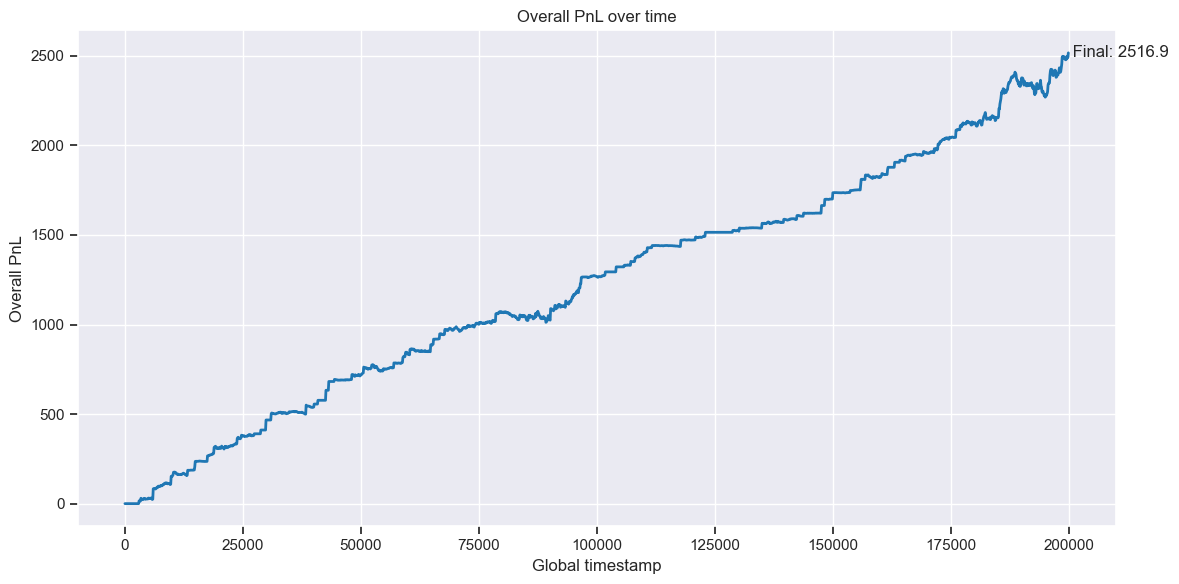

In [57]:
path = "data/version_1.log"
with open(path, "r", encoding="utf-8") as f:
    raw = json.load(f)

df_performance = pd.read_csv(StringIO(raw["activitiesLog"]), sep=";")

df_performance["global_timestamp"] = (df_performance["day"] - df_performance["day"].min()) * DAY_LENGTH + df_performance["timestamp"]

overall_pnl = (
    df_performance.groupby("global_timestamp", as_index=False)["profit_and_loss"]
      .sum()
      .sort_values(["global_timestamp"])
)

plt.figure(figsize=(12, 6))
plt.plot(overall_pnl["global_timestamp"], overall_pnl["profit_and_loss"], linewidth=2)

plt.title("Overall PnL over time")
plt.xlabel("Global timestamp")
plt.ylabel("Overall PnL")
plt.grid(True)

final_pnl = overall_pnl["profit_and_loss"].iloc[-1]
plt.text(
    overall_pnl["global_timestamp"].iloc[-1],
    final_pnl,
    f" Final: {final_pnl:.1f}",
    va="center"
)

plt.tight_layout()
plt.show()

**Performance by product**

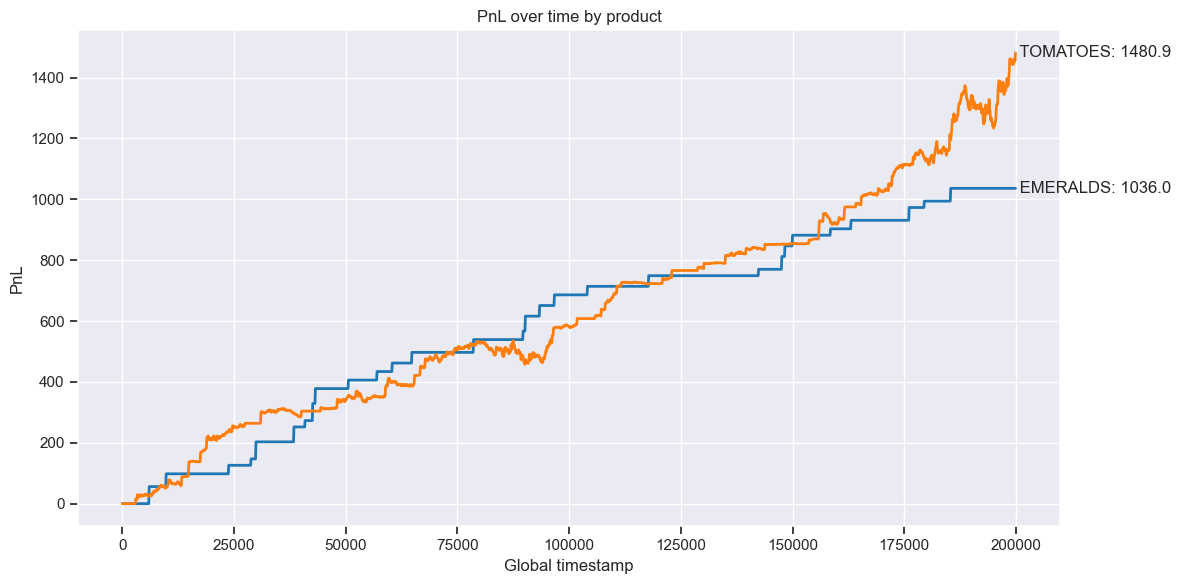

In [58]:
plt.figure(figsize=(12, 6))

for product, g in df_performance.groupby("product"):
    g = g.sort_values("global_timestamp")
    plt.plot(g["global_timestamp"], g["profit_and_loss"], linewidth=2, label=product)
    plt.text(
        g["global_timestamp"].iloc[-1],
        g["profit_and_loss"].iloc[-1],
        f" {product}: {g['profit_and_loss'].iloc[-1]:.1f}",
        va="center"
    )

plt.title("PnL over time by product")
plt.xlabel("Global timestamp")
plt.ylabel("PnL")
plt.grid(True)
plt.tight_layout()
plt.show()

A few clear points stand out from Version 1.

First, it made money overall. The run finished with a total profit of 2516.875 XIRECs and status `FINISHED`, so the strategy is viable as a first baseline rather than a dead end.

Second, the profit comes from both products. By the end of the run, EMERALDS contributes about 1036.0 and TOMATOES about 1480.875, which suggests the core architecture is not accidentally overfitted to a single market.

Third, TOMATOES is the stronger engine, while EMERALDS is the cleaner one. EMERALDS shows a step like PnL path with long flat periods followed by discrete jumps, which fits the earlier diagnosis exactly: a stable market, rare signals and high quality event trading. TOMATOES contributes more PnL, but the path is noisier and shows more giveback along the way.

Overall, Version 1 looks like a credible baseline. EMERALDS appears robust already, while TOMATOES is the more likely source of future improvement.